<a href="https://colab.research.google.com/github/mohamadarif03/belajar-modeling-sederhana/blob/main/clustering_customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

path = kagglehub.dataset_download("thedevastator/online-retail-transaction-data")

print("Path to dataset files:", path)

100%|██████████| 8.68M/8.68M [00:00<00:00, 36.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/online-retail-transaction-data/versions/1


In [3]:
import os
print(os.listdir(path))

['online_retail.csv']


## EDA

### Load & Inspect Awal

In [4]:
df = pd.read_csv(path + '/online_retail.csv')
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [6]:
df.describe()

,index,Quantity,UnitPrice,CustomerID
count,541909.00000,541909.000000,541909.000000,406829.000000
mean,270954.00000,9.552250,4.611114,15287.690570
std,156435.79785,218.081158,96.759853,1713.600303
min,0.00000,-80995.000000,-11062.060000,12346.000000
25%,135477.00000,1.000000,1.250000,13953.000000
50%,270954.00000,3.000000,2.080000,15152.000000
75%,406431.00000,10.000000,4.130000,16791.000000
max,541908.00000,80995.000000,38970.000000,18287.000000


### Visualisasi Data

<Axes: xlabel='Quantity', ylabel='Count'>

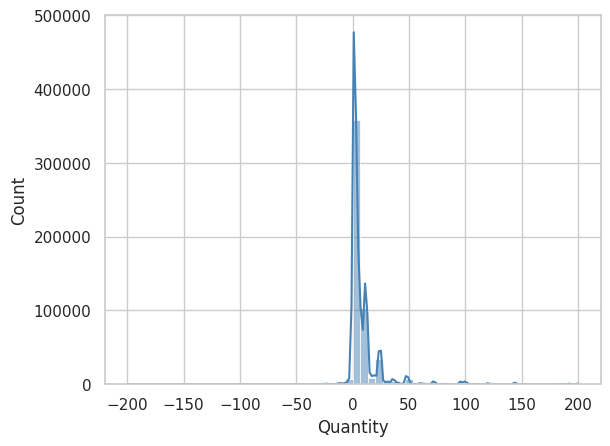

In [7]:
sns.set_theme(style="whitegrid", palette="muted")

sns.histplot(df[df["Quantity"].between(-200, 200)], x="Quantity", bins=60, kde=True, color='steelblue')

<Axes: xlabel='UnitPrice', ylabel='Count'>

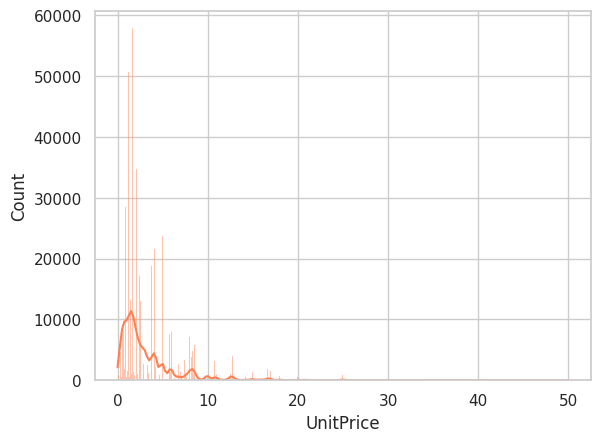

In [8]:
sns.histplot(df[df["UnitPrice"].between(0, 50)], x="UnitPrice", kde=True, color="coral")

### Check Missing Value

In [9]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Description,1454
CustomerID,135080


### Handling Missing Value

In [10]:
df_clean =  df.dropna(subset=["CustomerID"])
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

df_clean.shape

(397884, 9)

In [11]:
df_clean.describe()

,index,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000,397884.000000
mean,278462.993893,12.988238,3.116488,15294.423453
std,152770.852038,179.331775,22.097877,1713.141560
min,0.000000,1.000000,0.001000,12346.000000
25%,148333.750000,2.000000,1.250000,13969.000000
50%,284902.500000,6.000000,1.950000,15159.000000
75%,410074.250000,12.000000,3.750000,16795.000000
max,541908.000000,80995.000000,8142.750000,18287.000000


### Feature Engineering

In [12]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [13]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [14]:
import datetime as dt
latest_date = df_clean["InvoiceDate"].max() + dt.timedelta(days=1)

In [15]:
rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

rfm.rename(columns={
    'InvoiceDate': "Recency",
    'InvoiceNo': "Frequency",
    'TotalPrice': "MonetaryValue"
}, inplace=True)

display(rfm.head())
display(rfm.describe())

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


,Recency,Frequency,MonetaryValue
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


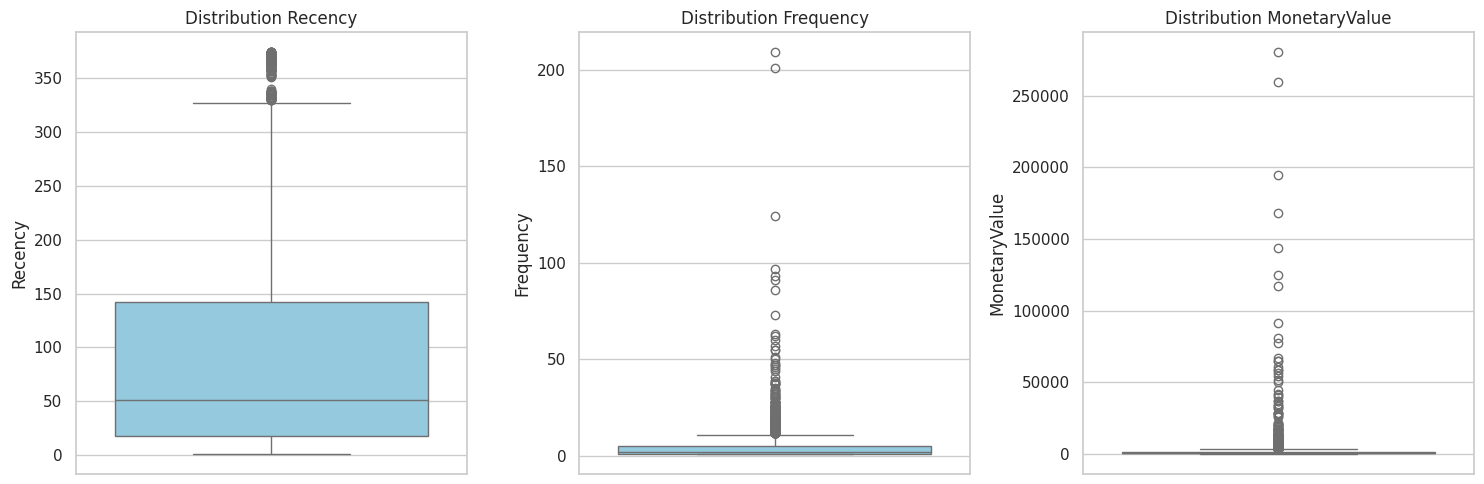

In [19]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm["Recency"], color="skyblue")
plt.title("Distribution Recency")

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm["Frequency"], color="skyblue")
plt.title("Distribution Frequency")

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm["MonetaryValue"], color="skyblue")
plt.title("Distribution MonetaryValue")

plt.tight_layout()
plt.show()

In [20]:
import numpy as np

rfm_log = rfm.copy()
rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["MonetaryValue"] = np.log1p(rfm_log["MonetaryValue"])

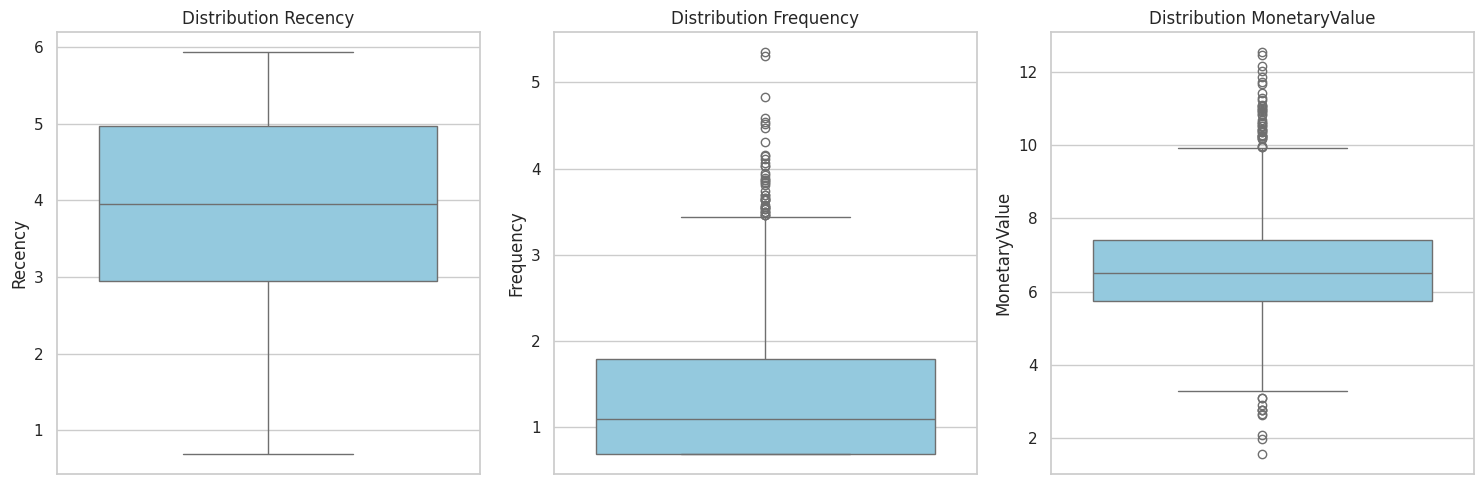

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm_log["Recency"], color="skyblue")
plt.title("Distribution Recency")

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm_log["Frequency"], color="skyblue")
plt.title("Distribution Frequency")

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm_log["MonetaryValue"], color="skyblue")
plt.title("Distribution MonetaryValue")

plt.tight_layout()
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=rfm_log.columns, index=rfm_log.index)

display(rfm_scaled.head())
display(rfm_scaled.describe().round(2))

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,1.461993,-0.955214,3.706225
12347.0,-2.038734,1.074425,1.411843
12348.0,0.373104,0.386304,0.716489
12349.0,-0.623086,-0.955214,0.698739
12350.0,1.424558,-0.955214,-0.618962


,Recency,Frequency,MonetaryValue
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.69
50%,0.09,-0.36,-0.06
75%,0.84,0.65,0.65
max,1.56,5.86,4.73


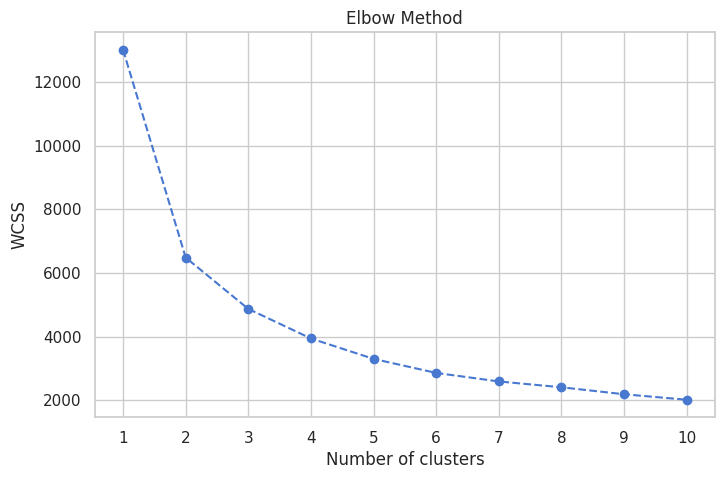

In [23]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(rfm_scaled)
rfm["Cluster"] = kmeans.labels_

display(rfm.head())

,Recency,Frequency,MonetaryValue,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,2


In [27]:
cluster_profile = rfm.groupby("Cluster").agg({
    'Recency':'mean',
    'Frequency':'mean',
    'MonetaryValue': ['mean', 'count']
}).round(2)

cluster_profile.columns = ['Recency_Mean', 'Frequency_Mean', 'Monetary_Mean', 'Jumlah_Pelanggan']
display(cluster_profile)

,Recency_Mean,Frequency_Mean,Monetary_Mean,Jumlah_Pelanggan
Cluster,,,,
0,44.46,3.37,1257.69,1696
1,17.07,13.27,7865.64,776
2,167.61,1.35,361.54,1866


In [29]:
rfm.rename(columns={'Cluster': 'Jenis Pelanggan'}, inplace=True)

mapping_cluster = {
    0: 'Pelanggan Regular',
    1: 'Pelanggan VIP',
    2: 'Pelanggan Churn'
}

rfm["Jenis Pelanggan"] = rfm["Jenis Pelanggan"].map(mapping_cluster)

display(rfm.head(10))

print(rfm["Jenis Pelanggan"].value_counts())

,Recency,Frequency,MonetaryValue,Jenis Pelanggan
CustomerID,,,,
12346.0,326,1,77183.60,Pelanggan Regular
12347.0,2,7,4310.00,Pelanggan VIP
12348.0,75,4,1797.24,Pelanggan Regular
12349.0,19,1,1757.55,Pelanggan Regular
12350.0,310,1,334.40,Pelanggan Churn
12352.0,36,8,2506.04,Pelanggan VIP
12353.0,204,1,89.00,Pelanggan Churn
12354.0,232,1,1079.40,Pelanggan Churn
12355.0,214,1,459.40,Pelanggan Churn


Jenis Pelanggan
Pelanggan Churn      1866
Pelanggan Regular    1696
Pelanggan VIP         776
Name: count, dtype: int64


In [30]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(rfm_scaled, kmeans.labels_)

print(f"Silhouette Score untuk K=3: {sil_score:.3f}")

Silhouette Score untuk K=3: 0.336
